In [4]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/HypnoticShield/ML/refs/heads/main/pre-ownedcars.csv')

In [7]:
numerical_cols = ['engine_capacity(CC)', 'km_driven', 'price', 'overall_cost']
data = df[numerical_cols]

In [8]:
data.fillna(data.mean(), inplace=True)

<ipython-input-8-a20208f658ce>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.fillna(data.mean(), inplace=True)


In [9]:
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data)

In [10]:
pca = PCA()  # Instantiate PCA
data_pca = pca.fit_transform(data_standardized)

In [11]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = pca.explained_variance_ratio_.cumsum()

In [12]:
print("Explained Variance Ratio (by Component):")
print(explained_variance_ratio)

Explained Variance Ratio (by Component):
[0.4044594  0.27013081 0.24994201 0.07546778]


In [13]:
num_components = sum(cumulative_variance < 0.95) + 1
print(f"\nNumber of Components to retain 95% variance: {num_components}")



Number of Components to retain 95% variance: 4


In [14]:
pca_selected = PCA(n_components=num_components)
data_pca_selected = pca_selected.fit_transform(data_standardized)

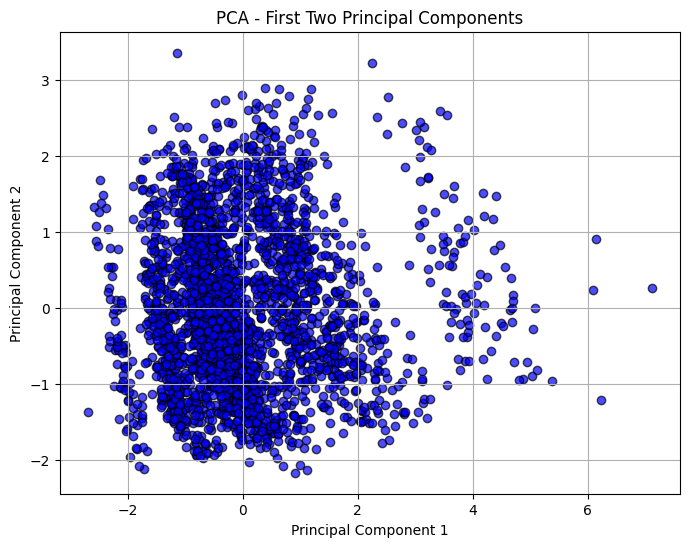

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(data_pca_selected[:, 0], data_pca_selected[:, 1], alpha=0.7, c='blue', edgecolor='k')
plt.title("PCA - First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()